In [127]:
from time import time
t00 = time()
import numpy as np


In [128]:
# Load clinical data
X_fn = './data/X_2018clinical.npy'
y_fn = './data/y_2018clinical.npy'
X = np.load(X_fn)
y = np.load(y_fn)
print(X.shape, y.shape)


(10000, 1000) (10000,)


In [129]:
from transformer import SpectraTransformer
import os
import torch
print(torch.__version__)                 # 应显示 cu121 / cu122 等后缀
print(torch.cuda.is_available())         # True
print(torch.cuda.get_device_name(0))     # 'NVIDIA GeForce RTX 5090'


2.7.1+cu128
True
NVIDIA GeForce RTX 5090


In [130]:
# Transformer parameters
input_dim = 1000
d_model = 128
nhead = 4
num_layers = 4
dim_feedforward = 512
dropout = 0.1
n_classes = 8 # instead of 30, we use the 8 empiric groupings
os.environ['CUDA_VISIBLE_DEVICES'] = '{}'.format(0)
cuda = torch.cuda.is_available()


In [131]:
# Load trained weights for demo
transformer = SpectraTransformer(input_dim=input_dim, d_model=d_model, 
                                nhead=nhead, num_layers=num_layers,
                                dim_feedforward=dim_feedforward, dropout=dropout,
                                n_classes=n_classes)
if cuda: transformer.cuda()

# Try to load pre-trained weights if available
pretrained_path = './clinical_pretrained_transformer_model.ckpt'
if os.path.exists(pretrained_path):
    transformer.load_state_dict(torch.load(pretrained_path, map_location=lambda storage, loc: storage))
    print("Loaded pre-trained transformer model")
else:
    print("No pre-trained model found, starting from scratch")


No pre-trained model found, starting from scratch


c:\Users\Kra\anaconda3\envs\jupyter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [132]:
# For each treatment group of 5 patients, patients are assigned to [train, train, train, val, test]
patient_idxs = []
for i in range(5):
    x = list(range(5))
    np.random.shuffle(x)
    patient_idxs.append(x)


In [133]:
# Sample train/val/te spectra
idx_tr, idx_val, idx_te = [], [], []
for group_idx, patient_list in enumerate(patient_idxs):
    print('Group {} patients'.format(group_idx))
    print(' Tr: {}'.format(patient_list[:3]))
    print(' Val: {}'.format(patient_list[3]))
    print(' Te : {}'.format(patient_list[4]))
    for j, patient in enumerate(patient_list):
        start_idx = 5 * 400 * group_idx + 400 * patient
        idx_range = list(range(start_idx, start_idx+400))
        # Randomly sample 10 spectra for each patient
        np.random.shuffle(idx_range)
        idx_sample = idx_range[:10]
        if j < 3:
            idx_tr.extend(idx_sample)
        elif j ==3:
            idx_val.extend(idx_sample)
        else:
            idx_te.extend(idx_sample)


Group 0 patients
 Tr: [0, 3, 4]
 Val: 1
 Te : 2
Group 1 patients
 Tr: [4, 3, 1]
 Val: 0
 Te : 2
Group 2 patients
 Tr: [2, 4, 0]
 Val: 1
 Te : 3
Group 3 patients
 Tr: [1, 2, 0]
 Val: 4
 Te : 3
Group 4 patients
 Tr: [1, 4, 2]
 Val: 3
 Te : 0


In [134]:
from datasets import spectral_dataloader
from training import run_epoch
from torch import optim


In [135]:
# Fine-tune Transformer
epochs = 50 # Change this number to ~30 for full training
batch_size = 30
t0 = time()
# Set up Adam optimizer
optimizer = optim.Adam(transformer.parameters(), lr=1e-3, betas=(0.5, 0.999))
# Set up dataloaders
dl_tr = spectral_dataloader(X, y, idxs=idx_tr,
    batch_size=batch_size, shuffle=True)
dl_val = spectral_dataloader(X, y, idxs=idx_val,
    batch_size=batch_size, shuffle=False)
dl_te = spectral_dataloader(X, y, idxs=idx_te,
    batch_size=batch_size, shuffle=False)
# Fine-tune Transformer for first fold
best_val = 0
no_improvement = 0
max_no_improvement = 5
print('Starting fine-tuning!')
for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    # Train
    acc_tr, loss_tr = run_epoch(epoch, transformer, dl_tr, cuda,
        training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}'.format(acc_tr))
    # Val
    acc_val, loss_val = run_epoch(epoch, transformer, dl_val, cuda,
        training=False, optimizer=optimizer)
    print('  Val acc: {:0.2f}'.format(acc_val))
    # Test
    acc_te, loss_te = run_epoch(epoch, transformer, dl_te, cuda,
        training=False, optimizer=optimizer)
    print('  Test acc: {:0.2f}'.format(acc_te))
    # Check performance for early stopping
    if acc_val > best_val or epoch == 0:
        best_val = acc_val
        no_improvement = 0
    else:
        no_improvement += 1
    if no_improvement >= max_no_improvement:
        print('Finished after {} epochs!'.format(epoch+1))
        break
print('Finished: {:0.2f}s'.format(time()-t0))


Starting fine-tuning!
 Epoch 1: 0.00s
  Train acc: 18.67
  Val acc: 20.00
  Test acc: 20.00
 Epoch 2: 39.44s
  Train acc: 20.00


KeyboardInterrupt: 

In [91]:
# Getting test indices
idx_te = []
for group_idx, patient_list in enumerate(patient_idxs):
    start_idx = 5 * 400 * group_idx + 400 * patient_list[-1]
    idx_te += list(range(start_idx, start_idx+400))
dl_te = spectral_dataloader(X, y, idxs=idx_te,
    batch_size=batch_size, shuffle=False)


In [92]:
from training import get_predictions
from scipy import stats

# Helper function to handle scipy version compatibility
def get_mode_value(data):
    """Get mode value compatible with different scipy versions"""
    try:
        mode_result = stats.mode(data)
        # Try new scipy format first (scipy >= 1.9)
        if hasattr(mode_result, 'mode'):
            mode_val = mode_result.mode
            if np.isscalar(mode_val):
                return mode_val
            else:
                return mode_val[0]
        # Fall back to old format (scipy < 1.9)
        else:
            return mode_result[0][0]
    except:
        # Fallback: use numpy for mode calculation
        values, counts = np.unique(data, return_counts=True)
        return values[np.argmax(counts)]


In [93]:
t0 = time()
# Make predictions on the 5 test patients
y_hat = get_predictions(transformer, dl_te, cuda)
# Subset y according to which patients are chosen for the test set to generate y_te
y_te = y[idx_te]
print('Finished: {:0.2f}s'.format(time()-t0))


Finished: 13.80s


In [ ]:
t0 = time()

# Experiment parameters
trials = 10000
n_spectra = 10

preds2018 = np.zeros((5,trials))
y_2018 = np.zeros((5, trials))

for i in range(5):
    y_2018[i] = y_te[400*i]
    for k  in range(trials):
        y_patient = y_hat[400*i:400*i+400]
        idxs = np.random.permutation(np.arange(len(y_patient)))[:n_spectra]
        preds2018[i,k] = get_mode_value(y_patient[idxs])

print('Ran {} trials: {:0.2f}s'.format(trials, time()-t0))


Ran 10000 trials: 6.98s


In [95]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from config import antibiotics, ab_order
%matplotlib inline


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000187E36CF420>
Traceback (most recent call last):
  File "c:\Users\Kra\anaconda3\envs\jupyter\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\Kra\anaconda3\envs\jupyter\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


C:\Users\Kra\AppData\Local\Temp\ipykernel_24812\2621760055.py:5: RuntimeWarning: invalid value encountered in divide
  cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]


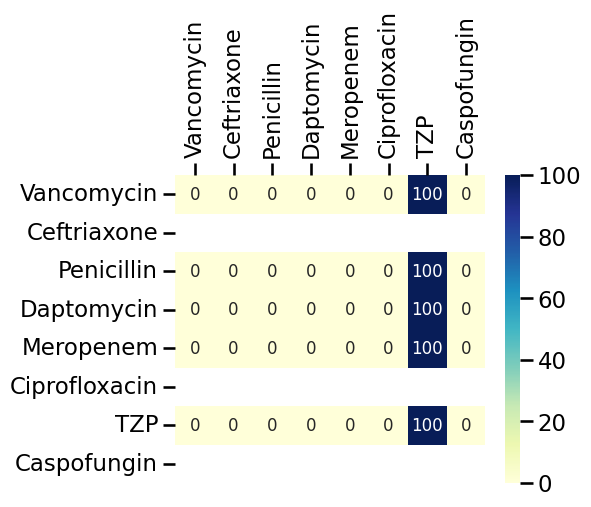

In [96]:
sns.set_context("talk", rc={"font":"Helvetica", "font.size":12})
label = [antibiotics[i] for i in ab_order]
cm = confusion_matrix(y_2018.flatten(), preds2018.flatten(), labels=ab_order)
plt.figure(figsize=(5, 4))
cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]
ax = sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.show()


In [97]:
# Load 2019 clinical data
X_fn = './data/X_2019clinical.npy'
y_fn = './data/y_2019clinical.npy'
X = np.load(X_fn)
y = np.load(y_fn)
print(X.shape, y.shape)


(2500, 1000) (2500,)


In [98]:
# For each treatment group of 5 patients, patients are assigned to [train, train, train, val, test]
patient_idxs = []
for i in range(5):
    x = list(range(5))
    np.random.shuffle(x)
    patient_idxs.append(x)


In [99]:
# Sample train/val/te spectra
idx_tr, idx_val, idx_te = [], [], []
for group_idx, patient_list in enumerate(patient_idxs):
    print('Group {} patients'.format(group_idx))
    print(' Tr: {}'.format(patient_list[:3]))
    print(' Val: {}'.format(patient_list[3]))
    print(' Te : {}'.format(patient_list[4]))
    for j, patient in enumerate(patient_list):
        start_idx = 5 * 100 * group_idx + 100 * patient
        idx_range = list(range(start_idx, start_idx+100))
        # Randomly sample 10 spectra for each patient
        np.random.shuffle(idx_range)
        idx_sample = idx_range[:10]
        if j < 3:
            idx_tr.extend(idx_sample)
        elif j ==3:
            idx_val.extend(idx_sample)
        else:
            idx_te.extend(idx_sample)


Group 0 patients
 Tr: [4, 1, 3]
 Val: 0
 Te : 2
Group 1 patients
 Tr: [0, 2, 3]
 Val: 4
 Te : 1
Group 2 patients
 Tr: [0, 1, 2]
 Val: 4
 Te : 3
Group 3 patients
 Tr: [4, 3, 1]
 Val: 0
 Te : 2
Group 4 patients
 Tr: [3, 1, 0]
 Val: 4
 Te : 2


In [100]:
# Fine-tune Transformer
epochs = 60 # Change this number to ~30 for full training
batch_size = 30
t0 = time()
# Set up Adam optimizer
optimizer = optim.Adam(transformer.parameters(), lr=1e-3, betas=(0.5, 0.999))
# Set up dataloaders
dl_tr = spectral_dataloader(X, y, idxs=idx_tr,
    batch_size=batch_size, shuffle=True)
dl_val = spectral_dataloader(X, y, idxs=idx_val,
    batch_size=batch_size, shuffle=False)
dl_te = spectral_dataloader(X, y, idxs=idx_te,
    batch_size=batch_size, shuffle=False)
# Fine-tune Transformer for first fold
best_val = 0
no_improvement = 0
max_no_improvement = 5
print('Starting fine-tuning!')
for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    # Train
    acc_tr, loss_tr = run_epoch(epoch, transformer, dl_tr, cuda,
        training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}'.format(acc_tr))
    # Val
    acc_val, loss_val = run_epoch(epoch, transformer, dl_val, cuda,
        training=False, optimizer=optimizer)
    print('  Val acc: {:0.2f}'.format(acc_val))
    # Test
    acc_te, loss_te = run_epoch(epoch, transformer, dl_te, cuda,
        training=False, optimizer=optimizer)
    print('  Test acc: {:0.2f}'.format(acc_te))
    # Check performance for early stopping
    if acc_val > best_val or epoch == 0:
        best_val = acc_val
        no_improvement = 0
    else:
        no_improvement += 1
    if no_improvement >= max_no_improvement:
        print('Finished after {} epochs!'.format(epoch+1))
        break
print('Finished: {:0.2f}s'.format(time()-t0))


Starting fine-tuning!
 Epoch 1: 0.00s
  Train acc: 25.33
  Val acc: 20.00
  Test acc: 20.00
Finished: 38.81s


In [101]:
# Getting test indices
idx_te = []
for group_idx, patient_list in enumerate(patient_idxs):
    start_idx = 5 * 100 * group_idx + 100 * patient_list[-1]
    idx_te += list(range(start_idx, start_idx+100))
dl_te = spectral_dataloader(X, y, idxs=idx_te,
    batch_size=batch_size, shuffle=False)


In [102]:
t0 = time()
# Make predictions on the 5 test patients
y_hat = get_predictions(transformer, dl_te, cuda)
# Subset y according to which patients are chosen for the test set to generate y_te
y_te = y[idx_te]
print('Finished: {:0.2f}s'.format(time()-t0))


Finished: 13.06s


In [103]:
t0 = time()

# Experiment parameters
trials = 10000
n_spectra = 10

preds2019 = np.zeros((5,trials))
y_2019 = np.zeros((5, trials))

for i in range(5):
    y_2019[i] = y_te[100*i]
    for k  in range(trials):
        y_patient = y_hat[100*i:100*i+100]
        idxs = np.random.permutation(np.arange(len(y_patient)))[:n_spectra]
        preds2019[i,k] = get_mode_value(y_patient[idxs])

print('Ran {} trials: {:0.2f}s'.format(trials, time()-t0))


Ran 10000 trials: 6.68s


C:\Users\Kra\AppData\Local\Temp\ipykernel_24812\3761724365.py:5: RuntimeWarning: invalid value encountered in divide
  cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]


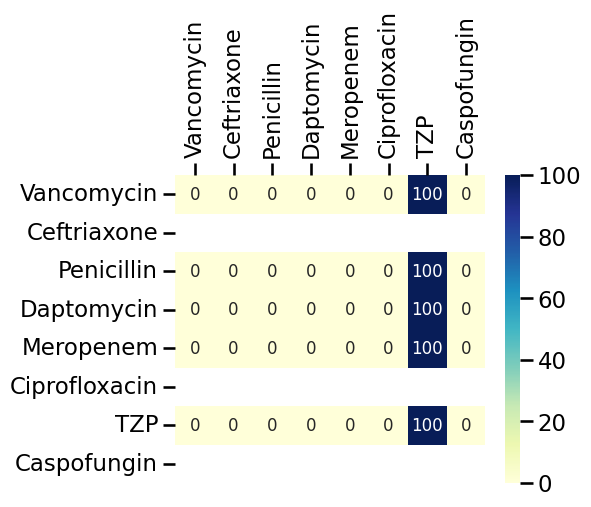


 This demo was completed in: 119.51s


In [104]:
sns.set_context("talk", rc={"font":"Helvetica", "font.size":12})
label = [antibiotics[i] for i in ab_order]
cm = confusion_matrix(y_2019.flatten(), preds2019.flatten(), labels=ab_order)
plt.figure(figsize=(5, 4))
cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]
ax = sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.show()

print('\n This demo was completed in: {:0.2f}s'.format(time()-t00))


In [105]:
from time import time
import torch
import numpy as np
import pandas as pd
from transformer import SpectraTransformer
from datasets import spectral_dataloader
from training import run_epoch
from torch import optim
import os

t00 = time()


In [ ]:
# Load clinical data
X_fn = './data/X_2018clinical.npy'
y_fn = './data/y_2018clinical.npy'
X = np.load(X_fn)
y = np.load(y_fn)
print(X.shape, y.shape)


(10000, 1000) (10000,)


In [107]:
# 配置
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
input_dim = 1000
n_classes = 8  # instead of 30, we use the 8 empiric antibiotic groupings
d_model = 128
nhead = 4
num_layers = 4
dim_feedforward = 512
dropout = 0.1

print(f"Using device: {DEVICE}")
print(f"Model: {num_layers} layers, {nhead} heads, {n_classes} classes")


Using device: cuda
Model: 4 layers, 4 heads, 8 classes


In [ ]:
# 🎯 Transfer Learning Strategy: Use 30-class Transformer for 8-class Clinical Task

print("🔄 Creating 8-class clinical transformer from 30-class pretrained model...")

# Step 1: Create a 30-class model first to load pretrained weights
print("Step 1: Loading 30-class pretrained transformer...")
temp_model_30 = SpectraTransformer(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    n_classes=30,  # Original 30 classes
    use_cls_token=True
).to(DEVICE)

# Load 30-class pretrained weights
pretrained_loaded = False
try:
    ckpt_30 = torch.load('./finetuned_transformer_model.ckpt', map_location=DEVICE)
    temp_model_30.load_state_dict(ckpt_30)
    print("✅ Successfully loaded 30-class pretrained transformer!")
    pretrained_loaded = True
except FileNotFoundError:
    print("⚠ No 30-class pretrained model found.")
except RuntimeError as e:
    print(f"✗ Error loading 30-class model: {e}")

# Step 2: Create 8-class model with same architecture (except classifier)
print("\nStep 2: Creating 8-class clinical model...")
model = SpectraTransformer(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    n_classes=n_classes,  # 8 classes for clinical task
    use_cls_token=True
).to(DEVICE)

# Step 3: Transfer weights from 30-class to 8-class model
if pretrained_loaded:
    print("Step 3: Transferring weights from 30-class to 8-class model...")
    
    # Get state dictionaries
    pretrained_dict = temp_model_30.state_dict()
    model_dict = model.state_dict()
    
    # Transfer all weights except the final classifier (fc layer)
    transferred_weights = {}
    skipped_weights = []
    
    for name, param in pretrained_dict.items():
        if name in model_dict:
            if param.size() == model_dict[name].size():
                transferred_weights[name] = param
            else:
                skipped_weights.append(f"{name}: {param.size()} -> {model_dict[name].size()}")
        else:
            skipped_weights.append(f"{name}: not found in 8-class model")
    
    # Update the 8-class model with transferred weights
    model_dict.update(transferred_weights)
    model.load_state_dict(model_dict)
    
    print(f"✅ Transferred {len(transferred_weights)}/{len(pretrained_dict)} layers")
    print(f"📋 Transfer summary:")
    print(f"   - Transferred: {len(transferred_weights)} layers")
    print(f"   - Skipped: {len(skipped_weights)} layers (mainly classifier)")
    
    # Show which layers were transferred vs skipped
    key_transferred = [k for k in transferred_weights.keys() if any(x in k for x in ['cls_token', 'token_embed', 'pos_encoder', 'encoder', 'norm'])]
    print(f"   - Key components transferred: {len(key_transferred)} (feature extraction layers)")
    print(f"   - New classifier head: fc layer ({d_model} -> {n_classes})")
    
    print("\n🎯 Transfer Learning Strategy:")
    print("   ✅ Feature extraction layers: PRETRAINED (from 30-class model)")
    print("   🆕 Classification head: RANDOMLY INITIALIZED (for 8-class task)")
    print("   📚 The model knows how to process spectra, but will learn clinical groupings")
    
else:
    print("⚠ No pretrained weights available - using random initialization")
    print("\n🎯 Training Strategy:")
    print("   🆕 All layers: RANDOMLY INITIALIZED")
    print("   📚 The model will learn everything from clinical data")

# Clean up temporary model
del temp_model_30
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\n✅ Final model configuration:")
print(f"   - Architecture: SpectraTransformer ({num_layers} layers, {nhead} heads)")
print(f"   - Input dimension: {input_dim}")
print(f"   - Output classes: {n_classes} (clinical antibiotic groupings)")
print(f"   - Transfer learning: {'Yes' if pretrained_loaded else 'No'}")
print(f"   - Device: {DEVICE}")

# Set model to training mode for fine-tuning
model.train()
print("\n🚀 Model ready for clinical fine-tuning!")


🔄 Creating 8-class clinical transformer from 30-class pretrained model...
Step 1: Loading 30-class pretrained transformer...
✅ Successfully loaded 30-class pretrained transformer!

Step 2: Creating 8-class clinical model...
Step 3: Transferring weights from 30-class to 8-class model...
✅ Transferred 54/56 layers
📋 Transfer summary:
   - Transferred: 54 layers
   - Skipped: 2 layers (mainly classifier)
   - Key components transferred: 54 (feature extraction layers)
   - New classifier head: fc layer (128 -> 8)

🎯 Transfer Learning Strategy:
   ✅ Feature extraction layers: PRETRAINED (from 30-class model)
   🆕 Classification head: RANDOMLY INITIALIZED (for 8-class task)
   📚 The model knows how to process spectra, but will learn clinical groupings

✅ Final model configuration:
   - Architecture: SpectraTransformer (4 layers, 4 heads)
   - Input dimension: 1000
   - Output classes: 8 (clinical antibiotic groupings)
   - Transfer learning: Yes
   - Device: cuda

🚀 Model ready for clinical 

c:\Users\Kra\anaconda3\envs\jupyter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [109]:
# For each treatment group of 5 patients, patients are assigned to [train, train, train, val, test]
patient_idxs = []
for i in range(5):
    x = list(range(5))
    np.random.shuffle(x)
    patient_idxs.append(x)


In [110]:
# Sample train/val/test spectra
idx_tr, idx_val, idx_te = [], [], []
for group_idx, patient_list in enumerate(patient_idxs):
    print('Group {} patients'.format(group_idx))
    print(' Tr: {}'.format(patient_list[:3]))
    print(' Val: {}'.format(patient_list[3]))
    print(' Te : {}'.format(patient_list[4]))
    for j, patient in enumerate(patient_list):
        start_idx = 5 * 400 * group_idx + 400 * patient
        idx_range = list(range(start_idx, start_idx+400))
        # Randomly sample 10 spectra for each patient
        np.random.shuffle(idx_range)
        idx_sample = idx_range[:10]
        if j < 3:
            idx_tr.extend(idx_sample)
        elif j == 3:
            idx_val.extend(idx_sample)
        else:
            idx_te.extend(idx_sample)


Group 0 patients
 Tr: [3, 4, 1]
 Val: 2
 Te : 0
Group 1 patients
 Tr: [3, 4, 2]
 Val: 1
 Te : 0
Group 2 patients
 Tr: [3, 1, 4]
 Val: 0
 Te : 2
Group 3 patients
 Tr: [1, 4, 2]
 Val: 3
 Te : 0
Group 4 patients
 Tr: [3, 0, 2]
 Val: 1
 Te : 4


In [111]:
# Fine-tune Transformer
epochs = 60  # Change this number to ~30 for full training
batch_size = 30
t0 = time()

# Set up dataloaders with proper number of workers for Windows
dl_tr = spectral_dataloader(X, y, idxs=idx_tr, batch_size=batch_size, shuffle=True, num_workers=0)
dl_val = spectral_dataloader(X, y, idxs=idx_val, batch_size=batch_size, shuffle=False, num_workers=0)
dl_te = spectral_dataloader(X, y, idxs=idx_te, batch_size=batch_size, shuffle=False, num_workers=0)

# Test data format with a small batch
print("Testing data format...")
for batch_idx, (inputs, targets) in enumerate(dl_tr):
    print(f"Original input shape: {inputs.shape}, Target shape: {targets.shape}")
    print(f"Input dtype: {inputs.dtype}, Target dtype: {targets.dtype}")
    
    # Move to device
    if DEVICE == 'cuda':
        inputs = inputs.cuda()
        targets = targets.cuda()
    
    # Test model forward pass
    try:
        with torch.no_grad():
            outputs = model(inputs)
            print(f"Model output shape: {outputs.shape}")
            print(f"Expected classes: {n_classes}, Got classes: {outputs.shape[1]}")
            
            if outputs.shape[1] == n_classes:
                print("✓ Data format test passed!")
            else:
                print(f"✗ Output dimension mismatch: expected {n_classes}, got {outputs.shape[1]}")
                
    except Exception as e:
        print(f"✗ Data format test failed: {e}")
        print("Error details:", str(e))
        
        # Try to fix common issues
        if "shape" in str(e).lower() or "dimension" in str(e).lower():
            print("Attempting data format fixes...")
            original_shape = inputs.shape
            
            # Try different input shapes
            if len(inputs.shape) == 2:  # (batch_size, features)
                inputs_fixed = inputs.unsqueeze(1)  # Add channel dimension
                print(f"Trying fixed shape: {inputs_fixed.shape}")
                try:
                    with torch.no_grad():
                        outputs = model(inputs_fixed)
                        print(f"✓ Fixed! Output shape: {outputs.shape}")
                except Exception as e2:
                    print(f"Still failed: {e2}")
        break
        
print(f"Test completed. Model expects input shape: (batch_size, 1, {input_dim})")
print(f"Target dtype should be: torch.long for CrossEntropyLoss")

# Set up Adam optimizer with more conservative learning rate
optimizer = optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999), weight_decay=1e-5)

# Fine-tune Transformer for first fold
best_val = 0
no_improvement = 0
max_no_improvement = 5
print('\nStarting fine-tuning on 2018 clinical data!')

for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    
    # Train
    acc_tr, loss_tr = run_epoch(epoch, model, dl_tr, DEVICE == 'cuda', 
                               training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}%, Loss: {:0.4f}'.format(acc_tr, loss_tr))
    
    # Validation  
    acc_val, loss_val = run_epoch(epoch, model, dl_val, DEVICE == 'cuda', 
                                 training=False)
    print('  Val acc: {:0.2f}%, Loss: {:0.4f}'.format(acc_val, loss_val))
    
    # Test
    acc_te, loss_te = run_epoch(epoch, model, dl_te, DEVICE == 'cuda', 
                               training=False)
    print('  Test acc: {:0.2f}%, Loss: {:0.4f}'.format(acc_te, loss_te))
    
    # Check performance for early stopping
    if acc_val > best_val or epoch == 0:
        best_val = acc_val
        no_improvement = 0
        # Save best model
        torch.save(model.state_dict(), 'clinical_finetuned_transformer_2018.ckpt')
        print(f"  → Saved best model (val acc: {best_val:.2f}%)")
    else:
        no_improvement += 1
    
    if no_improvement >= max_no_improvement:
        print('Early stopping after {} epochs!'.format(epoch+1))
        break

print('Finished 2018 fine-tuning: {:0.2f}s'.format(time()-t0))


Testing data format...
Original input shape: torch.Size([10, 1, 1000]), Target shape: torch.Size([10])
Input dtype: torch.float32, Target dtype: torch.float64
Model output shape: torch.Size([10, 8])
Expected classes: 8, Got classes: 8
✓ Data format test passed!
Original input shape: torch.Size([10, 1, 1000]), Target shape: torch.Size([10])
Input dtype: torch.float32, Target dtype: torch.float64
Model output shape: torch.Size([10, 8])
Expected classes: 8, Got classes: 8
✓ Data format test passed!
Original input shape: torch.Size([10, 1, 1000]), Target shape: torch.Size([10])
Input dtype: torch.float32, Target dtype: torch.float64
Model output shape: torch.Size([10, 8])
Expected classes: 8, Got classes: 8
✓ Data format test passed!
Original input shape: torch.Size([10, 1, 1000]), Target shape: torch.Size([10])
Input dtype: torch.float32, Target dtype: torch.float64
Model output shape: torch.Size([10, 8])
Expected classes: 8, Got classes: 8
✓ Data format test passed!
Original input shape:

In [112]:
# Getting test indices for all test patients (full 400 spectra each)
idx_te_full = []
for group_idx, patient_list in enumerate(patient_idxs):
    start_idx = 5 * 400 * group_idx + 400 * patient_list[-1]
    idx_te_full += list(range(start_idx, start_idx+400))
    
dl_te_full = spectral_dataloader(X, y, idxs=idx_te_full, batch_size=batch_size, shuffle=False, num_workers=0)


In [113]:
from training import get_predictions
from scipy import stats

t0 = time()
# Make predictions on the 5 test patients
y_hat = get_predictions(model, dl_te_full, DEVICE == 'cuda')
# Subset y according to which patients are chosen for the test set
y_te = y[idx_te_full]
print('Finished prediction: {:0.2f}s'.format(time()-t0))


Finished prediction: 0.77s


In [115]:
# Helper function to handle scipy version compatibility
def get_mode_value(data):
    """Get mode value compatible with different scipy versions"""
    try:
        mode_result = stats.mode(data)
        # Try new scipy format first (scipy >= 1.9)
        if hasattr(mode_result, 'mode'):
            mode_val = mode_result.mode
            if np.isscalar(mode_val):
                return mode_val
            else:
                return mode_val[0]
        # Fall back to old format (scipy < 1.9)
        else:
            return mode_result[0][0]
    except:
        # Fallback: use numpy for mode calculation
        values, counts = np.unique(data, return_counts=True)
        return values[np.argmax(counts)]

t0 = time()

# Experiment parameters
trials = 10000
n_spectra = 10

preds2018 = np.zeros((5, trials))
y_2018 = np.zeros((5, trials))

for i in range(5):
    y_2018[i] = y_te[400*i]
    for k in range(trials):
        y_patient = y_hat[400*i:400*i+400]
        idxs = np.random.permutation(np.arange(len(y_patient)))[:n_spectra]
        preds2018[i,k] = get_mode_value(y_patient[idxs])

print('Ran {} trials: {:0.2f}s'.format(trials, time()-t0))


Ran 10000 trials: 7.09s


In [117]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
from config import antibiotics, ab_order

# Alternative confusion matrix implementation (if sklearn not available)
def confusion_matrix_manual(y_true, y_pred, labels):
    """Manual implementation of confusion matrix"""
    n_labels = len(labels)
    cm = np.zeros((n_labels, n_labels), dtype=int)
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            cm[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    return cm

try:
    from sklearn.metrics import confusion_matrix
    use_sklearn = True
except ImportError:
    print("sklearn not available, using manual implementation")
    confusion_matrix = confusion_matrix_manual
    use_sklearn = False

%matplotlib inline


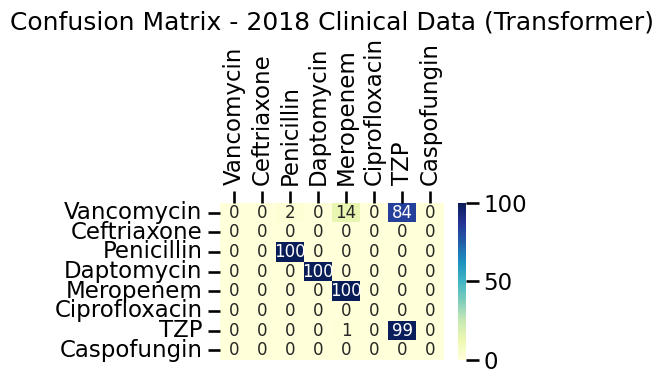

2018 Clinical accuracy: 79.8%


In [118]:
# Plot confusion matrix for 2018 results
sns.set_context("talk", rc={"font":"Helvetica", "font.size":12})
label = [antibiotics[i] for i in ab_order]

cm = confusion_matrix(y_2018.flatten(), preds2018.flatten(), labels=ab_order)
plt.figure(figsize=(5, 4))

# Normalize confusion matrix
cm_norm = 100 * cm / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)  # Add small epsilon to avoid division by zero

ax = sns.heatmap(cm_norm, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.title('Confusion Matrix - 2018 Clinical Data (Transformer)')
plt.tight_layout()
plt.show()

print(f"2018 Clinical accuracy: {np.mean(y_2018.flatten() == preds2018.flatten())*100:.1f}%")


In [119]:
# Load 2019 clinical data
X_fn = './data/X_2019clinical.npy'
y_fn = './data/y_2019clinical.npy'
X = np.load(X_fn)
y = np.load(y_fn)
print(X.shape, y.shape)


(2500, 1000) (2500,)


In [120]:
# For each treatment group of 5 patients, patients are assigned to [train, train, train, val, test]
patient_idxs_2019 = []
for i in range(5):
    x = list(range(5))
    np.random.shuffle(x)
    patient_idxs_2019.append(x)

# Sample train/val/test spectra for 2019 data
idx_tr_2019, idx_val_2019, idx_te_2019 = [], [], []
for group_idx, patient_list in enumerate(patient_idxs_2019):
    print('Group {} patients'.format(group_idx))
    print(' Tr: {}'.format(patient_list[:3]))
    print(' Val: {}'.format(patient_list[3]))
    print(' Te : {}'.format(patient_list[4]))
    for j, patient in enumerate(patient_list):
        start_idx = 5 * 100 * group_idx + 100 * patient
        idx_range = list(range(start_idx, start_idx+100))
        # Randomly sample 10 spectra for each patient
        np.random.shuffle(idx_range)
        idx_sample = idx_range[:10]
        if j < 3:
            idx_tr_2019.extend(idx_sample)
        elif j == 3:
            idx_val_2019.extend(idx_sample)
        else:
            idx_te_2019.extend(idx_sample)


Group 0 patients
 Tr: [1, 0, 2]
 Val: 3
 Te : 4
Group 1 patients
 Tr: [1, 0, 4]
 Val: 3
 Te : 2
Group 2 patients
 Tr: [2, 4, 3]
 Val: 1
 Te : 0
Group 3 patients
 Tr: [3, 0, 1]
 Val: 2
 Te : 4
Group 4 patients
 Tr: [2, 4, 1]
 Val: 0
 Te : 3


In [121]:
# Continue fine-tuning Transformer on 2019 data
epochs = 60  # Change this number to ~30 for full training
batch_size = 30
t0 = time()

# Set up Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.5, 0.999))

# Set up dataloaders for 2019 data
dl_tr_2019 = spectral_dataloader(X, y, idxs=idx_tr_2019, batch_size=batch_size, shuffle=True, num_workers=0)
dl_val_2019 = spectral_dataloader(X, y, idxs=idx_val_2019, batch_size=batch_size, shuffle=False, num_workers=0)
dl_te_2019 = spectral_dataloader(X, y, idxs=idx_te_2019, batch_size=batch_size, shuffle=False, num_workers=0)

# Continue fine-tuning on 2019 data
best_val_2019 = 0
no_improvement = 0
max_no_improvement = 5
print('Starting continued fine-tuning on 2019 clinical data!')

for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    
    # Train
    acc_tr, loss_tr = run_epoch(epoch, model, dl_tr_2019, DEVICE == 'cuda', 
                               training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}%'.format(acc_tr))
    
    # Validation
    acc_val, loss_val = run_epoch(epoch, model, dl_val_2019, DEVICE == 'cuda', 
                                 training=False)
    print('  Val acc: {:0.2f}%'.format(acc_val))
    
    # Test
    acc_te, loss_te = run_epoch(epoch, model, dl_te_2019, DEVICE == 'cuda', 
                               training=False)
    print('  Test acc: {:0.2f}%'.format(acc_te))
    
    # Check performance for early stopping
    if acc_val > best_val_2019 or epoch == 0:
        best_val_2019 = acc_val
        no_improvement = 0
        # Save best model
        torch.save(model.state_dict(), 'clinical_finetuned_transformer_2019.ckpt')
    else:
        no_improvement += 1
    
    if no_improvement >= max_no_improvement:
        print('Early stopping after {} epochs!'.format(epoch+1))
        break

print('Finished 2019 fine-tuning: {:0.2f}s'.format(time()-t0))


Starting continued fine-tuning on 2019 clinical data!
 Epoch 1: 0.00s
  Train acc: 82.67%
  Val acc: 72.00%
  Test acc: 42.00%
 Epoch 2: 0.34s
  Train acc: 92.00%
  Val acc: 78.00%
  Test acc: 74.00%
 Epoch 3: 0.58s
  Train acc: 91.33%
  Val acc: 76.00%
  Test acc: 54.00%
 Epoch 4: 0.82s
  Train acc: 92.00%
  Val acc: 86.00%
  Test acc: 74.00%
 Epoch 5: 1.07s
  Train acc: 86.67%
  Val acc: 82.00%
  Test acc: 70.00%
 Epoch 6: 1.33s
  Train acc: 92.00%
  Val acc: 90.00%
  Test acc: 66.00%
 Epoch 7: 1.59s
  Train acc: 98.00%
  Val acc: 82.00%
  Test acc: 70.00%
 Epoch 8: 1.83s
  Train acc: 100.00%
  Val acc: 74.00%
  Test acc: 72.00%
 Epoch 9: 2.07s
  Train acc: 100.00%
  Val acc: 78.00%
  Test acc: 70.00%
 Epoch 10: 2.31s
  Train acc: 100.00%
  Val acc: 74.00%
  Test acc: 74.00%
Finished 2019 fine-tuning: 2.55s


In [122]:
# Getting test indices for 2019 data (full 100 spectra per patient)
idx_te_full_2019 = []
for group_idx, patient_list in enumerate(patient_idxs_2019):
    start_idx = 5 * 100 * group_idx + 100 * patient_list[-1]
    idx_te_full_2019 += list(range(start_idx, start_idx+100))

dl_te_full_2019 = spectral_dataloader(X, y, idxs=idx_te_full_2019, batch_size=batch_size, shuffle=False, num_workers=0)

t0 = time()
# Make predictions on the 5 test patients from 2019
y_hat_2019 = get_predictions(model, dl_te_full_2019, DEVICE == 'cuda')
# Subset y according to which patients are chosen for the test set
y_te_2019 = y[idx_te_full_2019]
print('Finished 2019 prediction: {:0.2f}s'.format(time()-t0))


Finished 2019 prediction: 0.25s


In [123]:
t0 = time()

# Experiment parameters
trials = 10000
n_spectra = 10

preds2019 = np.zeros((5, trials))
y_2019 = np.zeros((5, trials))

for i in range(5):
    y_2019[i] = y_te_2019[100*i]
    for k in range(trials):
        y_patient = y_hat_2019[100*i:100*i+100]
        idxs = np.random.permutation(np.arange(len(y_patient)))[:n_spectra]
        preds2019[i,k] = get_mode_value(y_patient[idxs])

print('Ran {} trials for 2019 data: {:0.2f}s'.format(trials, time()-t0))


Ran 10000 trials for 2019 data: 6.79s


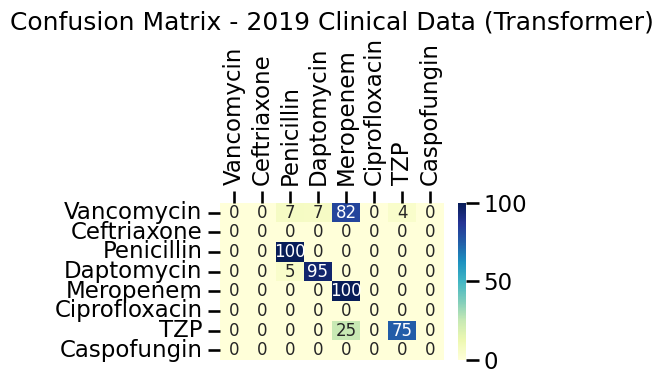

2019 Clinical accuracy: 74.1%

 This clinical fine-tuning demo was completed in: 312.95s


In [ ]:
# Plot confusion matrix for 2019 results
cm_2019 = confusion_matrix(y_2019.flatten(), preds2019.flatten(), labels=ab_order)
plt.figure(figsize=(5, 4))

# Normalize confusion matrix
cm_norm_2019 = 100 * cm_2019 / (cm_2019.sum(axis=1)[:, np.newaxis] + 1e-8)

ax = sns.heatmap(cm_norm_2019, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.title('Confusion Matrix - 2019 Clinical Data (Transformer)')
plt.tight_layout()
plt.show()

print(f"2019 Clinical accuracy: {np.mean(y_2019.flatten() == preds2019.flatten())*100:.1f}%")

print('\n This clinical fine-tuning demo was completed in: {:0.2f}s'.format(time()-t00))


In [126]:
# Optional: Save all results to files
results_df_2018 = pd.DataFrame({
    'patient_id': np.repeat(range(5), trials),
    'trial': np.tile(range(trials), 5),
    'true_treatment': y_2018.flatten(),
    'predicted_treatment': preds2018.flatten(),
    'year': '2018'
})

results_df_2019 = pd.DataFrame({
    'patient_id': np.repeat(range(5), trials), 
    'trial': np.tile(range(trials), 5),
    'true_treatment': y_2019.flatten(),
    'predicted_treatment': preds2019.flatten(),
    'year': '2019'
})

# Combine results
all_results = pd.concat([results_df_2018, results_df_2019], ignore_index=True)
all_results.to_csv('clinical_transformer_results.csv', index=False)

print("✓ Results saved to clinical_transformer_results.csv")
print(f"✓ 2018 model saved to clinical_finetuned_transformer_2018.ckpt")
print(f"✓ 2019 model saved to clinical_finetuned_transformer_2019.ckpt")


✓ Results saved to clinical_transformer_results.csv
✓ 2018 model saved to clinical_finetuned_transformer_2018.ckpt
✓ 2019 model saved to clinical_finetuned_transformer_2019.ckpt
